# **ONE RETAIL II**

In this project, we take on the role of a data scientist working for an online retail company. The main objective is to identify which customers are more likely to make repeat purchases.

This prediction will allow the business to design targeted strategies:
- **Loyalty actions** for customers with a high probability of returning.
- **Retention actions** for customers with a low probability of purchasing again.

The dataset contains historical transaction data, and our goal is to build a machine learning model that can estimate the likelihood of a customer making a future purchase.

---

## **The Dataset**

The dataset contains all transactions made by a UK-based online retail company between **December 1, 2009 and December 9, 2011**. The company sells unique gift items, and many of its customers are wholesalers.

**Columns:**

- **Invoice**: Unique identifier for each transaction. If the value starts with **"C"**, it indicates a **cancellation**.

- **StockCode**: Unique item code.

- **Description**: Name of the product.

- **Quantity**: Number of units of the product purchased in a transaction.

- **InvoiceDate**: Date and time when the transaction occurred.

- **Price**: Price per unit of the product (in GBP).

- **Customer ID**: Unique identifier for each customer.

- **Country**: Country where the customer is located.

---

## **Libraries**

In [1]:
import sys
sys.path.append('../src')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import optuna

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.inspection import permutation_importance

import cleaning
import visualizations

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **EDA**
### **Data Loading**

- Frist the data is loaded via `pandas` function `.read_excel`, specifying that all sheets will be loaded as a dataframe, creating this way a **dataframe of dataframes**.
- To handle all the **EDA** steps in a cohesive way, the next step is to **concatenate** both dataframes in a single one.
- Finally the concatenated dataframe is displayed to make sure all steps have been executed properly.

In [2]:
path = "../datasets/online_retail_II.xlsx"

# Read both sheets (all sheets) at once
dfs = pd.read_excel(path, sheet_name=None, verbose=True)

# Concatenate into one DataFrame
df = pd.concat(dfs.values(), ignore_index=True)
display(df.head(10))

Reading sheet Year 2009-2010
Reading sheet Year 2010-2011


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


### **Cleaning**

With the `.info()` function, the following information  about the dataset can be observed:
- **Size**: Number of Rows x Number of Columns
- **Datatypes** of each column: Here is easy to spot if there's some wrong datatype
- **Missing Values** (The `isna().sum()` functions are used eitherway to visualize better the missing values per column)
- **Memory usage** of the dataframe

In [3]:
print(df.info())
print(f"\nMissing Values per Column:\n{df.isna().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB
None

Missing Values per Column:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


By observing the `.info()` output, the next issues need to be adressed:
- Datatypes: 
    - Invoice: Should be `int`, however, some instances may have the letter **C**, indicating **cancelled invoice**. To adress this, a new column will be created, indicating with 0 the non cancellations and with 1 the cancellations. This way enabling the removal of all **C's** of the invoice columns allowing the casting to `int`.
- Missing Values: 
    - 4382 in **Description** column (Name of the product)
    - 243007 in **Customer ID** (Large amount considering the dataset has 1067371 entries)

In [4]:
# A copy of the original dataframe is made to not mess with the original data (Although in a real wolrd dscenario we must be cautious when copying large datasets like this one)
df_copy = df.copy()

#### **Datatypes**
**Invoice**

- By identifying which invoices had been cancelled, a new column ``Cancellation {0: Not cancelled, 1: Cancelled}`` is created.
    - Usually the creation of columns (feature engineering) is done after the cleaning process, however, in this case, since it was affecting directly to a column's datatype, the creation of this new column at such early stage has been considered the best aproach.
- Then all **C's** from the invoice column are deleted and then the column is casted into `int` datatype.

First, we search those **Invoice codes** that are not one of the following patterns:
- XXXXX...X, where X is any digit from 1 to 9
- CXXXX...X, same but adding the **C** for **cancellation**.

In [5]:
invoice_pattern = df_copy["Invoice"].astype(str).str.match(r"C?\d+")
df_copy[~invoice_pattern]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825443,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


The previous 6 intances didn't match the patterns mentioned, moreover **Customer ID** is `NaN` and the **Description** is definitely not a product's name.\
The best approach here would be to call our client or spoke to someone in our team that knows why those instances are the way they are.\
 However, in this situation we cannot ask anybody, so the best aproach will be to just delete those instances.

In [6]:
# Delete previous instances
df_copy = df_copy[invoice_pattern]

# Create Cancellation column
df_copy["Cancellation"] = df_copy["Invoice"].astype(str).str.startswith("C").astype(int)

# Remove "C" from Invoice and convert to integer
df_copy["Invoice"] = df_copy["Invoice"].astype(str).str.replace("C", "", regex=False)
df_copy["Invoice"] = df_copy["Invoice"].astype(int)

# Check result
display(df_copy[df_copy["Cancellation"] == 1].head(20))
print(df_copy["Invoice"].dtype)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Cancellation
178,489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,1
179,489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,1
180,489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,1
181,489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,1
182,489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,1
183,489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia,1
184,489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia,1
185,489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia,1
186,489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,1
196,489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom,1


int32


#### **Missing Values**

**Description & Customer ID**

Without the **Customer_ID** there's no way we can answer whether if that customer is likely to buy again or not. Even though the number of missing IDs is very large, there's no extra information that helps the inputation of those values, so the best approach will be to delete those instances.

In [7]:
df_copy = df_copy.dropna(subset="Customer ID")
df_copy["Customer ID"] = df_copy["Customer ID"].astype(int)
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 824364 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Invoice       824364 non-null  int32         
 1   StockCode     824364 non-null  object        
 2   Description   824364 non-null  object        
 3   Quantity      824364 non-null  int64         
 4   InvoiceDate   824364 non-null  datetime64[ns]
 5   Price         824364 non-null  float64       
 6   Customer ID   824364 non-null  int32         
 7   Country       824364 non-null  object        
 8   Cancellation  824364 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(3), int64(1), object(3)
memory usage: 53.5+ MB


Luckily, the missing values in the **Description** column where also related with some of the missing **IDs**. In case there was some missing value on the **Description** column, before labeling the missing product name as **NO DESCRIPTION** or something similar, each **StockCode** of the missing value should be searched to see if the product's name exist in another invoice or not.

#### **Duplicated**

To treat the duplicates, we must assume that, two identical instances (all values in the columns are the same) correspond to a input mistake. Since there is not an explanation, a priori, on why a client will purchase the same quantity of the same product, at the same time in the same invoice but register it as another product instead of adding the quantity to one of the instances.
- Working under this assumption, all duplicated instances will be removed.

In [8]:
df_copy = df_copy.drop_duplicates()
df_copy.duplicated().sum()

0

#### **Impossible Values**

To end the cleaning stage, the existence of impossible values or writing typos must be adressed.

##### **Categorical Columns**

- **StockCode**

In [9]:
df_copy[~df_copy["StockCode"].astype(str).str.match(r"^[A-Z\d]+$")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Cancellation
18410,490943,BANK CHARGES,Bank Charges,-1,2009-12-08 14:08:00,15.0,16703,United Kingdom,1
18466,490948,BANK CHARGES,Bank Charges,1,2009-12-08 14:29:00,15.0,16805,United Kingdom,0
94431,498269,BANK CHARGES,Bank Charges,1,2010-02-17 15:03:00,15.0,16928,United Kingdom,0
148098,503497,BANK CHARGES,Bank Charges,1,2010-04-01 12:07:00,15.0,17539,United Kingdom,0
149063,503571,BANK CHARGES,Bank Charges,-1,2010-04-01 15:45:00,15.0,17539,United Kingdom,1


By searching those **StockCodes** that doesn't contain Numbers and capital letters, we've found that not all Products are actually items, as we can see in these **Bank Charges** instnaces.

- **Description**

In [10]:
df_copy[~df_copy["Description"].astype(str).str.match(r"^[A-Z\s\d\-\+\'\&\"\/\,\.\!\(\)]+$")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Cancellation
361,489517,21705,BAG 500g SWIRLY MARBLES,1,2009-12-01 11:34:00,1.65,16329,United Kingdom,0
618,489526,46000S,POLYESTER FILLER PAD 40x40cm,2,2009-12-01 11:50:00,1.45,12533,Germany,0
619,489526,20964,POLYESTER FILLER PAD 60x40cm,3,2009-12-01 11:50:00,2.55,12533,Germany,0
735,489535,D,Discount,-1,2009-12-01 12:11:00,9.00,15299,United Kingdom,1
736,489535,D,Discount,-1,2009-12-01 12:11:00,19.00,15299,United Kingdom,1
...,...,...,...,...,...,...,...,...,...
1065620,581469,21704,BAG 250g SWIRLY MARBLES,1,2011-12-08 19:28:00,0.85,14606,United Kingdom,0
1065742,581475,21705,BAG 500g SWIRLY MARBLES,24,2011-12-09 08:39:00,0.39,13069,United Kingdom,0
1067002,581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498,United Kingdom,1
1067073,581514,21705,BAG 500g SWIRLY MARBLES,84,2011-12-09 11:20:00,0.39,17754,United Kingdom,0


Here we searched for strange product names, even though no writting typo has been found, now we know, corroborating with the previous cell, that not all instances correspond to actual prodcuts, as it can be seen in the **Discount** and **Manual** instnaces.

Finally, a check in the **Country** column is done, to make sure no typos and repeated countries are found.
- **Country**

In [11]:
df_copy["Country"].unique()

array(['United Kingdom', 'France', 'USA', 'Belgium', 'Australia', 'EIRE',
       'Germany', 'Portugal', 'Japan', 'Denmark', 'Netherlands', 'Poland',
       'Spain', 'Channel Islands', 'Italy', 'Cyprus', 'Greece', 'Norway',
       'Austria', 'Sweden', 'United Arab Emirates', 'Finland',
       'Switzerland', 'Unspecified', 'Nigeria', 'Malta', 'RSA',
       'Singapore', 'Bahrain', 'Thailand', 'Israel', 'Lithuania',
       'West Indies', 'Korea', 'Brazil', 'Canada', 'Iceland', 'Lebanon',
       'Saudi Arabia', 'Czech Republic', 'European Community'],
      dtype=object)

It appears an "Unspecified" country, no need to remove it 

##### **Numerical Columns**

Using the `.describe()` method, impossible numerical values, outliers or extreme values can be easily spotted. Comparing the **min or max** value with the **mean or median** value of the column.

In [12]:
df_copy.describe()

,Invoice,Quantity,InvoiceDate,Price,Customer ID,Cancellation
count,797885.000000,797885.000000,797885,797885.000000,797885.000000,797885.000000
mean,537364.043833,12.602980,2011-01-02 13:17:34.141160704,3.702732,15313.062777,0.023048
min,489434.000000,-80995.000000,2009-12-01 07:45:00,0.000000,12346.000000,0.000000
25%,514374.000000,2.000000,2010-07-02 09:47:00,1.250000,13964.000000,0.000000
50%,536707.000000,5.000000,2010-12-02 12:33:00,1.950000,15228.000000,0.000000
75%,561902.000000,12.000000,2011-07-31 15:50:00,3.750000,16788.000000,0.000000
max,581587.000000,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,1.000000
std,26906.673792,191.670371,NaN,71.392549,1696.466663,0.150057


Thanks to this table, some unusual values can be easily spotted:
- **Quantity**: While the median (50%) is at 5 and the mean is at 12,6 (inflated due to the outliers), the min and max values are 4 orders of magnitud larger, indicating a clear outlier.
- **Price**: Here the situation is similar, with the difference that the minimum value is 0, wierd for a product to be free, but is not necesarily an impossible value. However the max value is clearly an outlier.

All the other numerical variables seem to be clear from impossible values and outliers.


### **Descriptive Statistics**
#### **Outliers & Distributions**

Next, the distributions of the only useful numerical columns, **Quantity** and **Price** will be displayed.

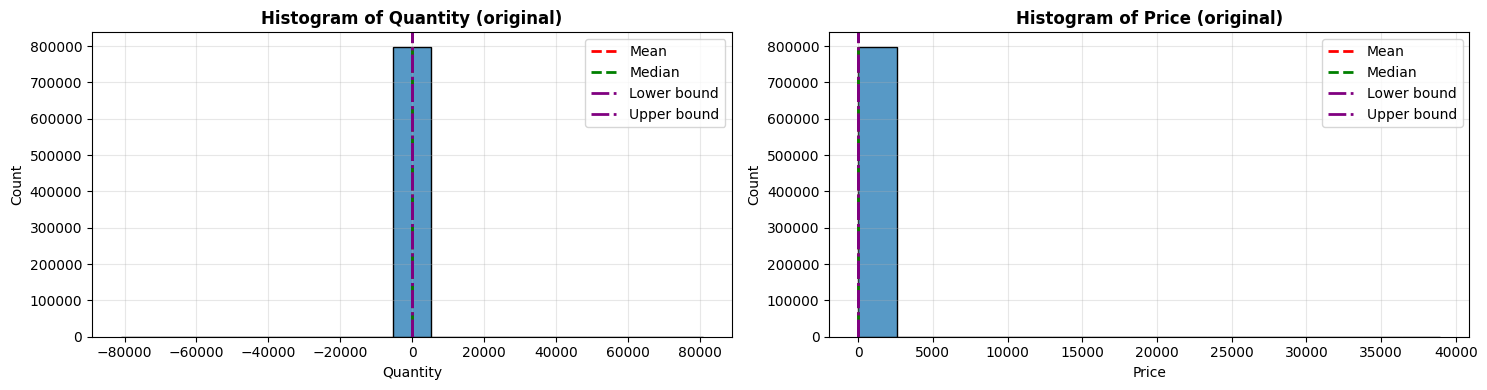

In [13]:
num_cols = ["Quantity", "Price"]
visualizations.distribution(df_copy, num_cols)

As it can be seen, both distributions are heavily affected by extreme values, as no difference can be appreciated between the mean, meadian (Q2), and lower and upper bound of the IQR. Instead of removing the data outside the IQR boundaries, let's observe the distribution applyting a tranformation that allow us to visualize positive and non-positive values, since the logarithmic scaling doesn't work with non-positive values, and the `MinMaxScaler` and `StandardScaler` don't change the way the values are distributed.

The following transformation will be applied (only to visualize the data):
$$x_{transformed​}=sign(x)⋅log(1+∣x∣)$$

- **`sign(x)`** returns:
  - `+1` if \( x > 0 \), `0` if \( x = 0 \), `-1` if \( x < 0 \)

- **Why this form?**
  - Standard log cannot handle **negative values or zero**
  - \( \log(1 + |x|) \) ensures all inputs are valid and reduces skewness
  - `sign(x)` restores the original positive/negative direction

- **What problem does it solve?**
  - Allows transforming data with **negatives and zeros**
  - Keeps the distribution shape interpretable for visualization

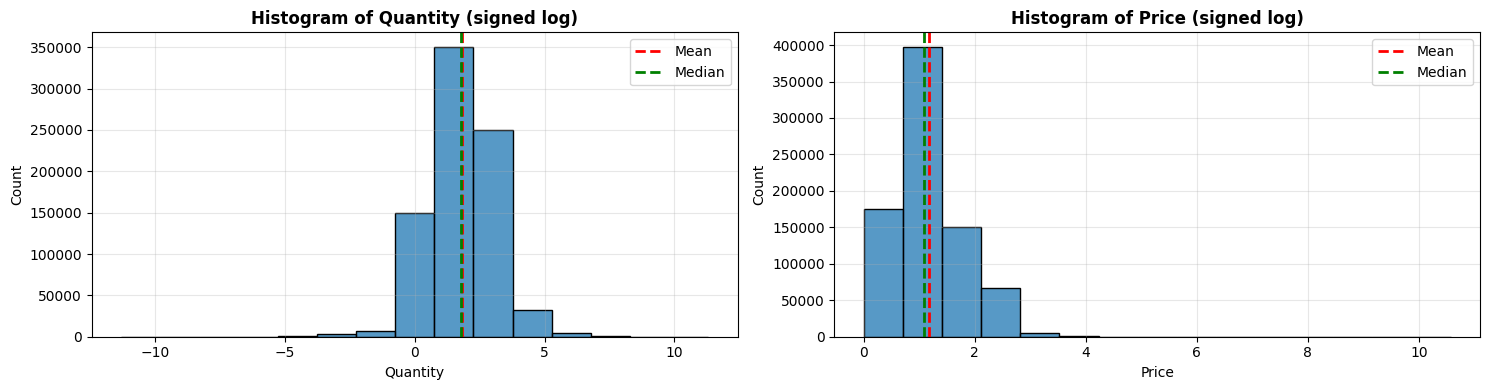

In [14]:
visualizations.distribution(df_copy, num_cols, scale=True)

With the data scaled, both distributions can be easily observed. If the IQR process would have been applied to treat the outliers, we would had lost a large portion of the dataset (and not necesarily outliers). For future steps involving predictive modelling with machine learning algorithms, we must recall that the data must be scaled before training the models.


### **Visualizations**

Before proceeding with the visualizations, some feature engineering will be done.

In [15]:
# Time features Year, Month, Quarter and Weekday
df_copy["Year"] = df_copy["InvoiceDate"].dt.year
df_copy["Month"] = df_copy["InvoiceDate"].dt.month
df_copy["Quarter"] = df_copy["InvoiceDate"].dt.quarter
df_copy["Weekday"] = df_copy["InvoiceDate"].dt.day_name()

# Total price of the product quantity x price
df_copy["TotalPrice"] = df_copy["Quantity"] * df_copy["Price"]

**Country**

c:\Users\HP\Desktop\Master\6. ML_DL\ML_Project\notebooks\../src\visualizations.py:198: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels([f"{x*100:.1f}%" for x in axes[0,1].get_xticks()])


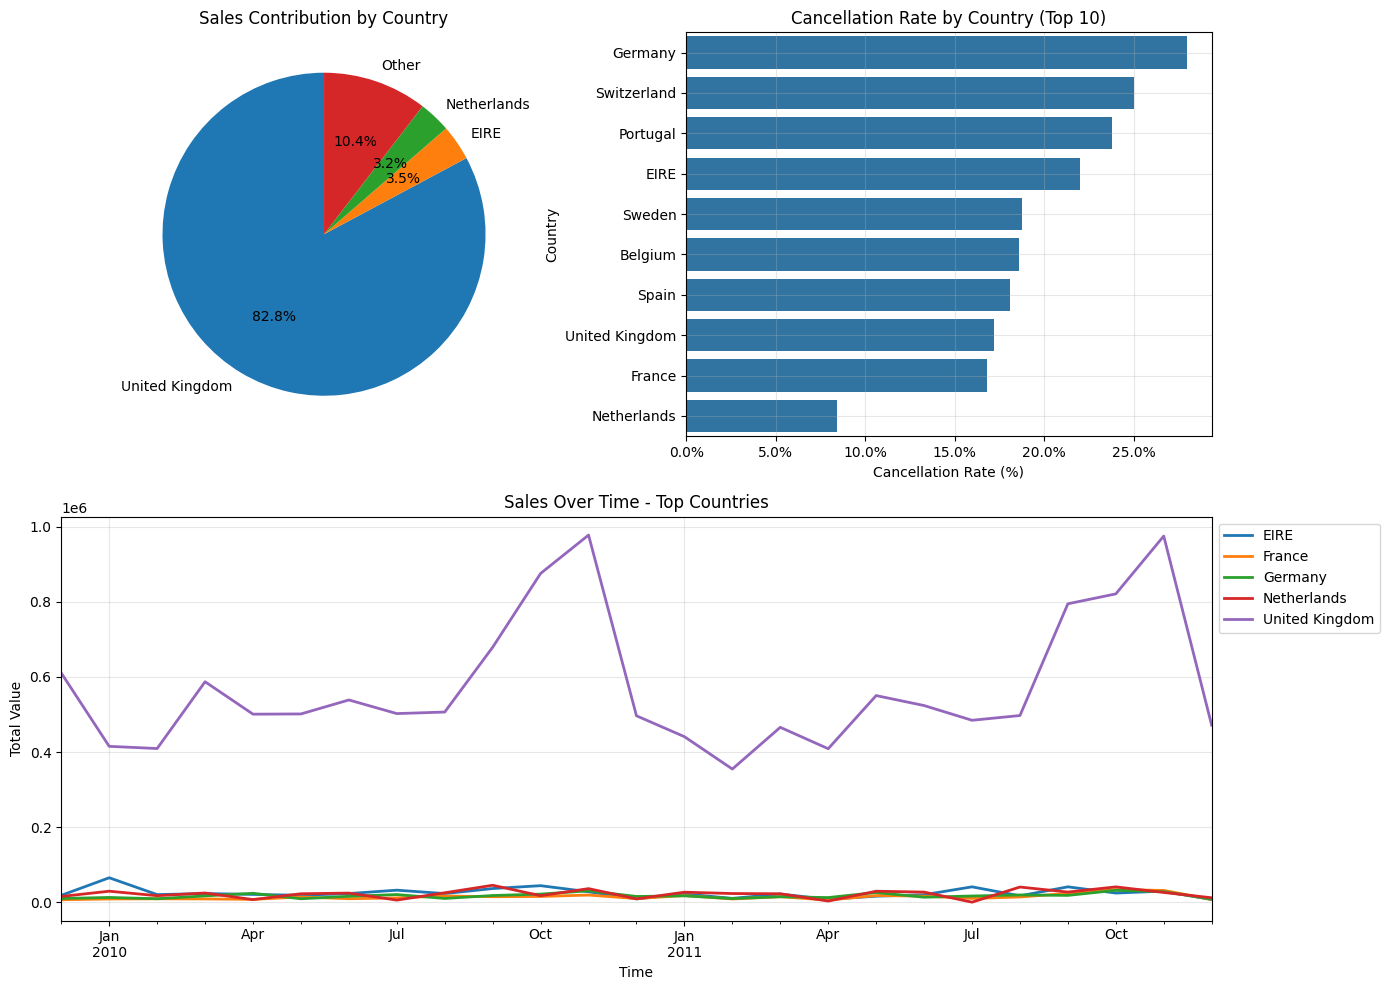

In [16]:
visualizations.country(df_copy)

From both, the piechart and the lineplot, can be derived that the customers in the United Kingdom (same country our company is located in) are almost the totally of the income, with a 82.8% of total sales contribution. Related to this matter, the lineplot gives us more information realted with the seasonality of the sales, highlighting the increase of sales from August to Novemberi both 2010 and 2011.

From the sidebar chart, are displayed the countries that have a higher rate of cancellations with respect to their number of unique invoices.

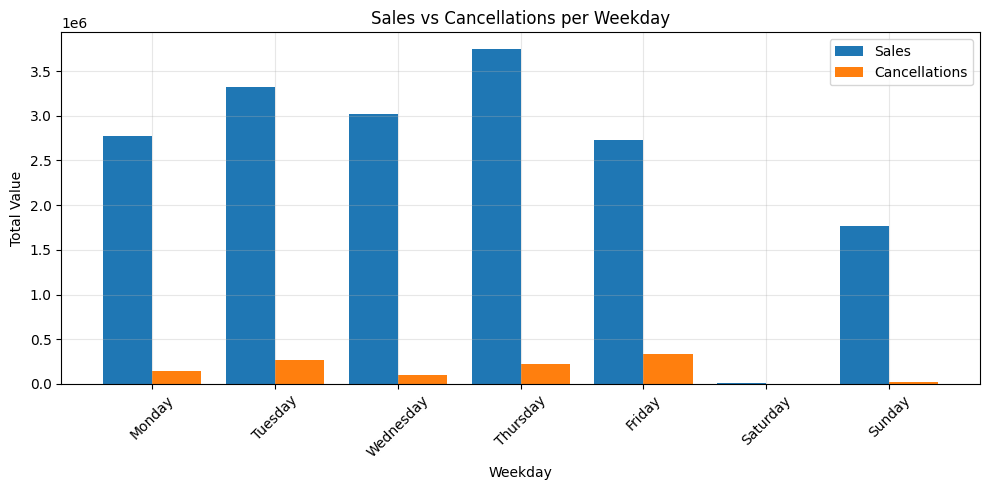

In [17]:
visualizations.weekday(df_copy)

Since a montlhy seasonality has been spotted in the previous visualization, here we can see if there's any pattern in sales/cancellations with respect the weekday. Despite the decrease in sales and cancellations at the weekend, no other significant pattern can be derived.

**Sales per Product**

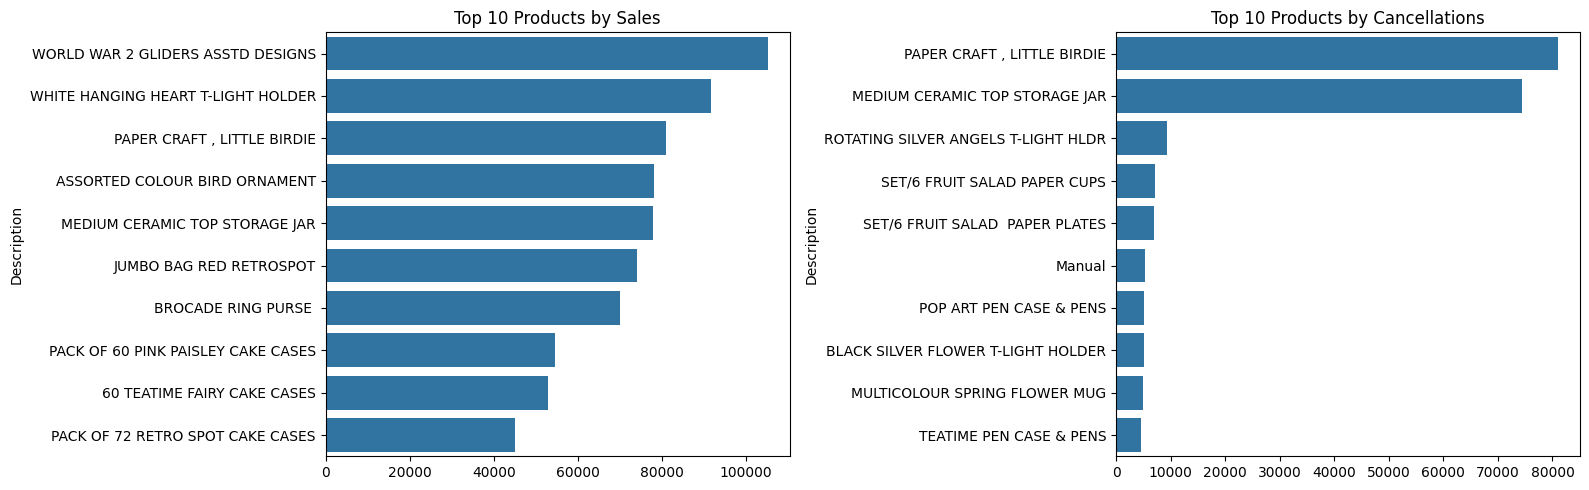

In [18]:
# Aggregate
product_sales = df_copy[df_copy["Quantity"] > 0].groupby("Description")["Quantity"].sum().sort_values(ascending=False)
product_cancellations = df_copy[df_copy["Quantity"] < 0].groupby("Description")["Quantity"].sum().abs().sort_values(ascending=False)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=product_sales.values[:10], y=product_sales.index[:10], ax=axes[0])
axes[0].set_title("Top 10 Products by Sales")

sns.barplot(x=product_cancellations.values[:10], y=product_cancellations.index[:10], ax=axes[1])
axes[1].set_title("Top 10 Products by Cancellations")

plt.tight_layout()
plt.show()

#### **Customer Analysis**

In [19]:
customer_df = df_copy[df_copy["Cancellation"] == 0].groupby("Customer ID").agg({
    "Invoice": "nunique",          # number of orders
    "Quantity": "sum",               # total items bought
    "TotalPrice": "sum",             # total money spent
    "InvoiceDate": ["min", "max"]    # first & last purchase
})

# Flatten columns
customer_df.columns = ["NumOrders", "TotalQuantity", "TotalSpent", "FirstPurchase", "LastPurchase"]

customer_df.head()

,NumOrders,TotalQuantity,TotalSpent,FirstPurchase,LastPurchase
Customer ID,,,,,
12346,12,74285,77556.46,2009-12-14 08:34:00,2011-01-18 10:01:00
12347,8,2967,4921.53,2010-10-31 14:20:00,2011-12-07 15:52:00
12348,5,2714,2019.40,2010-09-27 14:59:00,2011-09-25 13:13:00
12349,4,1624,4428.69,2010-04-29 13:20:00,2011-11-21 09:51:00
12350,1,197,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


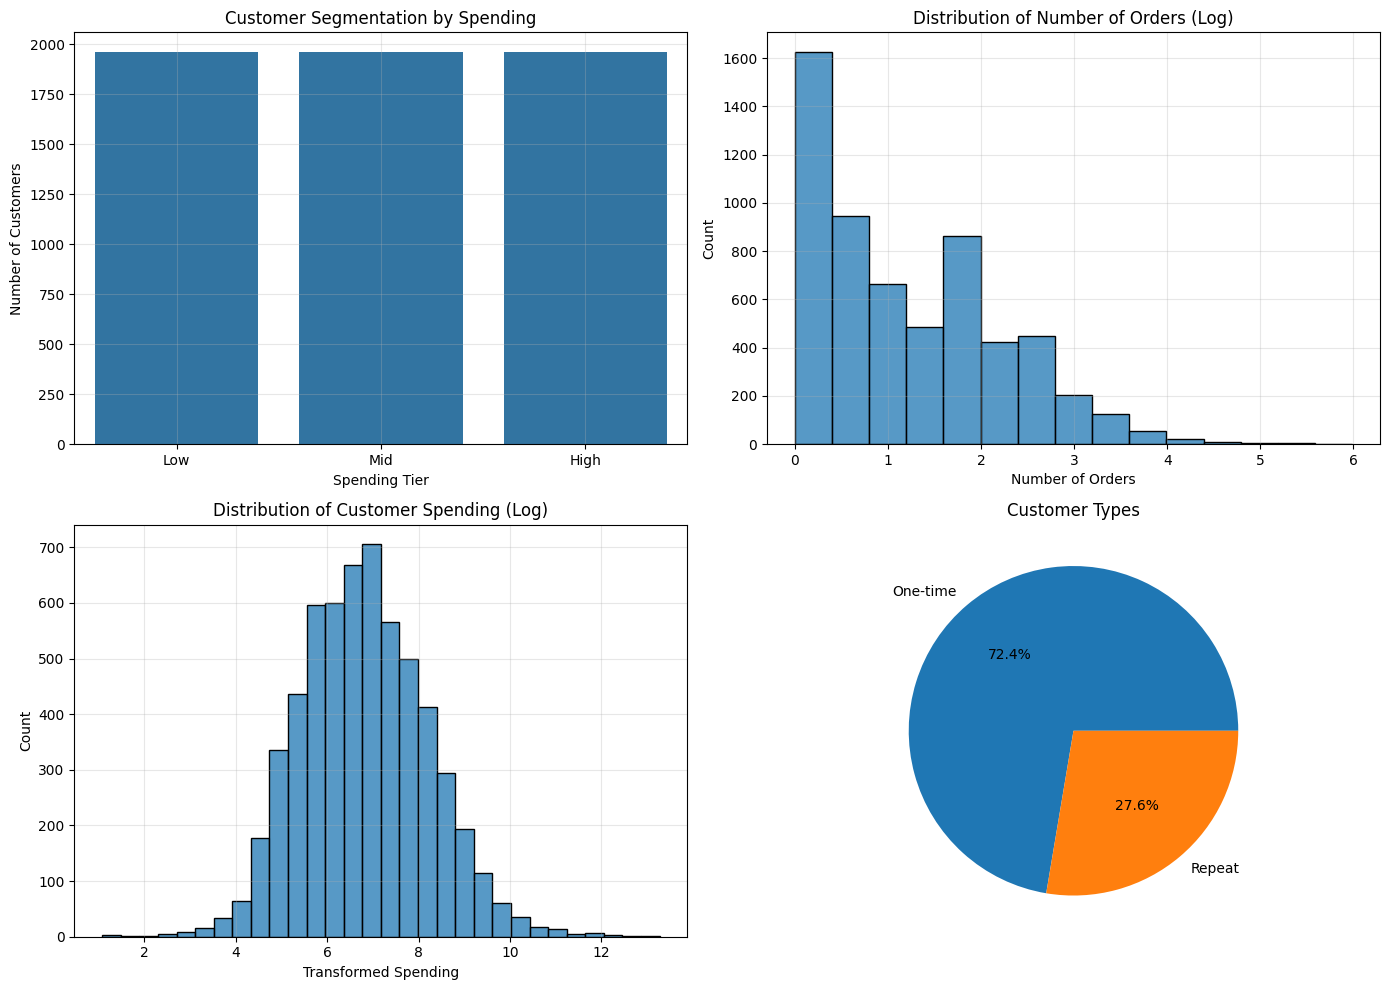

In [20]:
visualizations.customer(customer_df)

**Customer segmentation by spending (BarChart)**
- Looks like there's exactly the same amount of Low/Mid and High spending tier customers. Suggesting this company gets its a high portion of their revenue to the group of high tier spending customers.

**Distribution of Number of Orders (Log)**
- The distribution has been logarithmic scaled for better visualization. The Log of this distribution follows an exponential-like distribution, so the real distribution follows the same behaviour but with a more agressive slope.

**Distribution of Customers Spending (Log)**
- Like the previous one, this distribution has been scaled with the logarithm. Here the distribution resembles to a normal with positive kurtosis (higher peak and fatter tails). For the real distribution we would see only 2-4 bins located at the center while little representation for the larger values in absolute value (large positive and large negative).

**Customer Types (PieChart)**
- From all the customers, only a 27.6% has ordered more than one invoice.

---
## **Feature Engineering: Customer-Level Features**

In this project, we shift from transaction-level data to a **customer-level perspective**, since our goal is to predict customer behavior (whether a customer is likely to purchase again).

To achieve this, we aggregate transactional data and construct meaningful features that describe each customer's behavior.


Now, each row in the dataset represents a transaction, but:
- A single customer can have multiple transactions
- Behavioral patterns emerge only when we **aggregate activity per customer**

Therefore, we build a dataset where:
- Each row = one customer
- Each column = a behavioral feature


**RFM Features**

- **Recency (R)**: How recently the customer made a purchase, engagement measure.  
- **Frequency (F)**: How often the customer purchases, loyalty measure.
- **Monetary (M)**: How much the customer spends.


`Nevertheless, we have to take into consideration that we could NOT use ALL THE DATA, otherwise we will have **data leakage** in the target variable, since it will be created from the existing features`

- The data will be splitted into:
    - First 80%, as training data
    - Last 20%, to create the target labels as which customers from the first 80% appear again as buyers in this new 20%. Having this way an approximation of customers that are likely to buy again.

In [21]:
# Here we are going to use the first 80% of the data 
split_date = df_copy["InvoiceDate"].quantile(0.8)

# Past data (features)
df_past = df_copy[df_copy["InvoiceDate"] <= split_date]

# Future data (target)
df_future = df_copy[df_copy["InvoiceDate"] > split_date]


#### **RFM Features**

Customer behavior is summarized using the RFM framework. These features capture how recently a customer purchased, how frequently they buy, and how much they spend, providing a strong baseline for modeling customer value and engagement.

In [22]:
# Rebuild using past data only
df_sales_past = df_past[df_past["Quantity"] > 0]

snapshot_date = df_past["InvoiceDate"].max()

rfm = df_sales_past.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days, # Days that each customer have since last invoice
    "Invoice": "nunique",
    "TotalPrice": "sum",
})

rfm.columns = ["Recency", "Frequency", "Monetary"]


#### **Incorporating Cancellations**

Cancellation-related features are added to capture potentially risky or inconsistent customer behavior. These variables help identify customers with higher return rates or negative purchasing patterns.

In [23]:
df_cancel_past = df_past[df_past["Quantity"] < 0]

cancel_features = df_cancel_past.groupby("Customer ID").agg({
    "Invoice": "nunique",
    "TotalPrice": "sum"
}).abs()

cancel_features.columns = ["NumCancellations", "CancelValue"]

rfm = rfm.merge(cancel_features, how="left", on="Customer ID")
rfm = rfm.fillna(0)

rfm["CancelRate"] = rfm["NumCancellations"] / (rfm["Frequency"] + 1)
rfm["CancelValueRatio"] = rfm["CancelValue"] / (rfm["Monetary"] + 1)


#### **Additional Features**

Additional features are created to enrich customer profiles, including geographic information and behavioral metrics such as lifetime, average order value, and purchase intensity. These features provide more detailed insights into customer habits.

In [24]:
# Country (most frequent per customer)
customer_country = (
    df_copy.groupby("Customer ID")["Country"]
    .agg(lambda x: x.mode()[0])
)
#rfm = rfm.merge(customer_country, on="Customer ID", how="left")


# Customer lifetime
customer_dates = df_sales_past.groupby("Customer ID").agg({
    "InvoiceDate": ["min", "max"]
})

customer_dates.columns = ["FirstPurchase", "LastPurchase"]

customer_dates["CustomerLifetime"] = (
    customer_dates["LastPurchase"] - customer_dates["FirstPurchase"]
).dt.days
rfm = rfm.merge(customer_dates["CustomerLifetime"], on="Customer ID", how="left")


# Average order value
rfm["AvgOrderValue"] = rfm["Monetary"] / (rfm["Frequency"] + 1)

# Average quantity
quantity_per_customer = df_sales_past.groupby("Customer ID")["Quantity"].sum()
rfm["AvgQuantity"] = quantity_per_customer / (rfm["Frequency"] + 1)

# Purchase frequency rate
rfm["PurchaseFrequencyRate"] = rfm["Frequency"] / (rfm["CustomerLifetime"] + 1)

In [25]:
rfm.head()

,Recency,Frequency,Monetary,NumCancellations,CancelValue,CancelRate,CancelValueRatio,CustomerLifetime,AvgOrderValue,AvgQuantity,PurchaseFrequencyRate
Customer ID,,,,,,,,,,,
12346,237,12,77556.46,5.0,77608.20,0.384615,1.000654,400,5965.881538,5714.230769,0.029925
12347,41,6,3402.39,0.0,0.00,0.000000,0.000000,274,486.055714,299.857143,0.021818
12348,160,4,1709.40,0.0,0.00,0.000000,0.000000,189,341.880000,499.400000,0.021053
12349,319,3,2671.14,1.0,24.15,0.250000,0.009038,181,667.785000,248.250000,0.016484
12350,221,1,334.40,0.0,0.00,0.000000,0.000000,0,167.200000,98.500000,1.000000


### **Target variable** 

The target is build by identifying thos customers that appear both in the present dataset and future dataset.

In [26]:
# Customers who bought in the future
future_customers = df_future[df_future["Cancellation"] == 0]["Customer ID"].unique()

# Build target
rfm["Target"] = rfm.index.isin(future_customers).astype(int)

rfm["Target"].value_counts()

Target
0    3010
1    2284
Name: count, dtype: int64

By doing the 80-20 partition, we end up with:
- 3010 customers that didn't order back
- 2284 customers that did order back

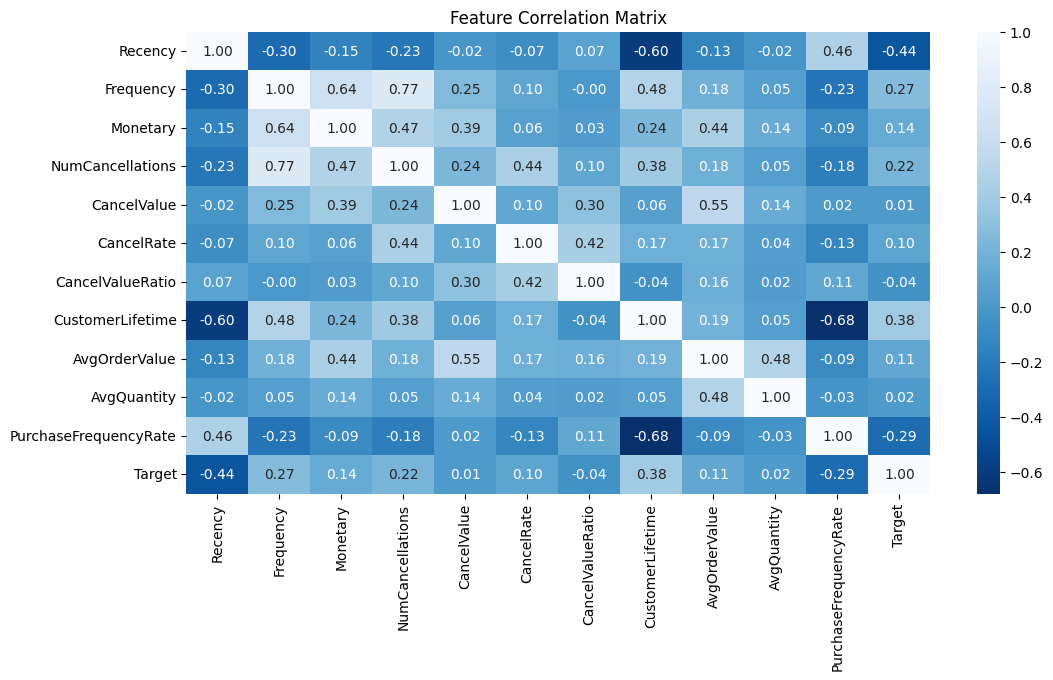

In [27]:
#rfm_nc = rfm.drop("Country", axis=1)

plt.figure(figsize=(12,6))
sns.heatmap(rfm.corr(), annot=True, fmt='.2f', cmap='Blues_r')
plt.title("Feature Correlation Matrix")
plt.show()

The correlation matrix highlights relationships between customer features and the target variable.

- **Recency** shows the strongest relationship with the target (-0.44), indicating that customers who purchased more recently are significantly more likely to buy again. This aligns with expectations and confirms Recency as a key predictive feature.

- **Frequency** has a moderate positive correlation with the target (0.27), suggesting that customers who purchase more often are more likely to return.

- **CustomerLifetime** also shows a positive correlation with the target (0.38), meaning long-term customers tend to be more loyal.

- **PurchaseFrequencyRate** has a negative correlation with the target (-0.29), likely due to its inverse relationship with CustomerLifetime, indicating some redundancy between these features.


- Strong correlations exist between:
  - **Frequency and NumCancellations (0.77)** → more active customers naturally have more cancellations
  - **Frequency and Monetary (0.64)** → frequent buyers spend more
  - **AvgOrderValue and CancelValue (0.55)** → higher-value orders relate to higher cancellation values

- **CustomerLifetime and Recency (-0.60)** show a strong negative relationship, as expected:
  - Customers active for longer tend to have more recent purchases


Some features are moderately to highly correlated:
- Frequency, Monetary, and NumCancellations
- CustomerLifetime and PurchaseFrequencyRate

While tree-based models can handle this, linear models (like Logistic Regression) may be affected.

---
## **Preprocessing**

Before training the model, the following preprocessing steps are applied to the customer-level dataset.


**1. Handle Missing Values**

After feature engineering, some customers may have missing values (e.g., no cancellations).

These are filled with zeros, assuming:
- No cancellations → 0
- No activity → 0


**2. Feature Selection**

We remove:
- Identifiers (e.g., Customer ID)
- Target variable (separated from features)

**3. Encoding**
- Encode categroical variables (Country)

**4. Feature Scaling**

Since features have different ranges:
- Monetary → large values
- Rates → small values

We apply scaling to:
- Improve model performance
- Ensure fair feature contribution


**5. Train-Test Split**

We split the data into:
- Training set → model learns patterns
- Test set → model evaluation

This ensures unbiased performance measurement.

In [28]:
# -------- Encoding --------
#df_model = pd.get_dummies(rfm, columns= ["Country"], drop_first=True)
df_model = rfm.copy()
# -------- Separate target --------
X = df_model.drop(columns=["Target"])
y = df_model["Target"]

# -------- Train-test split --------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------- Scaling --------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---
## **Modelling**

In this section, we train multiple classification models to predict whether a customer will purchase again.

We compare:
- Logistic Regression (baseline)
- Random Forest (ensemble)
- XGBoost (boosting)

We use:
- Cross-validation for robust evaluation
- Optuna for hyperparameter tuning
- ROC AUC as the main metric

Finally, we compare models using:
- ROC curves
- Confusion matrices
- Performance metrics (Accuracy, Precision, Recall, F1-score)

### **Logistic Regression**

In [29]:
def objective_logreg(trial):
    C = trial.suggest_loguniform("C", 1e-4, 10)

    model = LogisticRegression(C=C, max_iter=1000)

    score = cross_val_score(
        model, X_train_scaled, y_train,
        cv=5, scoring="roc_auc"
    ).mean()

    return score

study_logreg = optuna.create_study(direction="maximize")
study_logreg.optimize(objective_logreg, n_trials=100)

best_logreg = LogisticRegression(**study_logreg.best_params, max_iter=1000)
best_logreg.fit(X_train_scaled, y_train)

[I 2026-03-25 18:51:14,395] A new study created in memory with name: no-name-cb886b54-0e00-40fe-b74a-b9161dc6e996
C:\Users\HP\AppData\Local\Temp\ipykernel_9048\153898351.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform("C", 1e-4, 10)
[I 2026-03-25 18:51:14,453] Trial 0 finished with value: 0.7742111129487629 and parameters: {'C': 0.0005095073472602736}. Best is trial 0 with value: 0.7742111129487629.
C:\Users\HP\AppData\Local\Temp\ipykernel_9048\153898351.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C = trial.suggest_loguniform("C", 1e-4, 10)
[I 2026-03-25 18:51:14,527] Trial 1 finished with value: 0.7904286713548594 and parameters

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",4.145153142043813
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- 

### **SVM**

In [30]:
def objective_svm(trial):
    params = {
        "C": trial.suggest_float("C", 1e-3, 100, log=True),
        "kernel": trial.suggest_categorical("kernel", ["linear", "rbf"]),
        "gamma": trial.suggest_categorical("gamma", ["scale", "auto"])
    }

    model = SVC(
        **params,
        probability=True  # needed for ROC AUC
    )

    score = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    return score

study_svm = optuna.create_study(direction="maximize")
study_svm.optimize(objective_svm, n_trials=30)

best_svm = SVC(
    **study_svm.best_params,
    probability=True
)

best_svm.fit(X_train_scaled, y_train)

[I 2026-03-25 18:51:24,633] A new study created in memory with name: no-name-06a4a436-6d11-4031-9fe9-9a14d79ca131
[I 2026-03-25 18:51:30,657] Trial 0 finished with value: 0.7770474368564704 and parameters: {'C': 0.43368967385949136, 'kernel': 'rbf', 'gamma': 'auto'}. Best is trial 0 with value: 0.7770474368564704.
[I 2026-03-25 18:51:35,151] Trial 1 finished with value: 0.79062659939868 and parameters: {'C': 0.14438833112025298, 'kernel': 'linear', 'gamma': 'auto'}. Best is trial 1 with value: 0.79062659939868.
[I 2026-03-25 18:51:41,136] Trial 2 finished with value: 0.7775293381317387 and parameters: {'C': 0.07715883890276642, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 1 with value: 0.79062659939868.
[I 2026-03-25 18:51:45,085] Trial 3 finished with value: 0.7820931805505775 and parameters: {'C': 0.004646457257570294, 'kernel': 'linear', 'gamma': 'auto'}. Best is trial 1 with value: 0.79062659939868.
[I 2026-03-25 18:51:48,391] Trial 4 finished with value: 0.7656128142239329 an

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.3556388313934529
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### **KNN**

In [31]:
def objective_knn(trial):
    params = {
        "n_neighbors": trial.suggest_int("n_neighbors", 3, 30),
        "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
        "p": trial.suggest_int("p", 1, 2)  # 1=Manhattan, 2=Euclidean
    }

    model = KNeighborsClassifier(**params)

    score = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    return score

study_knn = optuna.create_study(direction="maximize")
study_knn.optimize(objective_knn, n_trials=30)

best_knn = KNeighborsClassifier(**study_knn.best_params)
best_knn.fit(X_train_scaled, y_train)

[I 2026-03-25 18:53:19,575] A new study created in memory with name: no-name-1febf690-e74b-4eee-937c-2d52fae24e68
[I 2026-03-25 18:53:19,734] Trial 0 finished with value: 0.7846563910378783 and parameters: {'n_neighbors': 23, 'weights': 'uniform', 'p': 2}. Best is trial 0 with value: 0.7846563910378783.
[I 2026-03-25 18:53:19,839] Trial 1 finished with value: 0.772457525816835 and parameters: {'n_neighbors': 11, 'weights': 'uniform', 'p': 1}. Best is trial 0 with value: 0.7846563910378783.
[I 2026-03-25 18:53:19,930] Trial 2 finished with value: 0.7824731453231333 and parameters: {'n_neighbors': 17, 'weights': 'distance', 'p': 1}. Best is trial 0 with value: 0.7846563910378783.
[I 2026-03-25 18:53:20,023] Trial 3 finished with value: 0.7303888026715659 and parameters: {'n_neighbors': 4, 'weights': 'uniform', 'p': 2}. Best is trial 0 with value: 0.7846563910378783.
[I 2026-03-25 18:53:20,106] Trial 4 finished with value: 0.786763646604539 and parameters: {'n_neighbors': 20, 'weights': '

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",30
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",1
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### **Naive Bayes**

In [32]:
def objective_nb(trial):
    var_smoothing = trial.suggest_float("var_smoothing", 1e-12, 1e-6, log=True)

    model = GaussianNB(var_smoothing=var_smoothing)

    score = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    return score

study_nb = optuna.create_study(direction="maximize")
study_nb.optimize(objective_nb, n_trials=30)

best_nb = GaussianNB(**study_nb.best_params)
best_nb.fit(X_train_scaled, y_train)

[I 2026-03-25 18:53:21,975] A new study created in memory with name: no-name-1c73bb61-6597-48a0-bcb9-65acc0df020d
[I 2026-03-25 18:53:22,002] Trial 0 finished with value: 0.767752930570221 and parameters: {'var_smoothing': 6.843771670493595e-08}. Best is trial 0 with value: 0.767752930570221.
[I 2026-03-25 18:53:22,029] Trial 1 finished with value: 0.767752930570221 and parameters: {'var_smoothing': 8.242667201736082e-10}. Best is trial 0 with value: 0.767752930570221.
[I 2026-03-25 18:53:22,057] Trial 2 finished with value: 0.767752930570221 and parameters: {'var_smoothing': 1.0203275549871006e-08}. Best is trial 0 with value: 0.767752930570221.
[I 2026-03-25 18:53:22,084] Trial 3 finished with value: 0.767752930570221 and parameters: {'var_smoothing': 4.006632090973965e-09}. Best is trial 0 with value: 0.767752930570221.
[I 2026-03-25 18:53:22,111] Trial 4 finished with value: 0.767752930570221 and parameters: {'var_smoothing': 2.3042894314359422e-07}. Best is trial 0 with value: 0.7

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",6.843771670493595e-08


### **Random Forest** 

In [33]:
def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10)
    }

    model = RandomForestClassifier(**params, random_state=42)

    score = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring="roc_auc"
    ).mean()

    return score

study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective_rf, n_trials=30)

best_rf = RandomForestClassifier(**study_rf.best_params, random_state=42)
best_rf.fit(X_train, y_train)

[I 2026-03-25 18:53:22,829] A new study created in memory with name: no-name-3286e4d2-cfe1-45c8-9daa-7b046c1be1dd
[I 2026-03-25 18:53:33,611] Trial 0 finished with value: 0.7993566094733567 and parameters: {'n_estimators': 360, 'max_depth': 12, 'min_samples_split': 8}. Best is trial 0 with value: 0.7993566094733567.
[I 2026-03-25 18:53:40,804] Trial 1 finished with value: 0.8024899386595591 and parameters: {'n_estimators': 305, 'max_depth': 9, 'min_samples_split': 7}. Best is trial 1 with value: 0.8024899386595591.
[I 2026-03-25 18:53:49,459] Trial 2 finished with value: 0.803828774311446 and parameters: {'n_estimators': 401, 'max_depth': 8, 'min_samples_split': 4}. Best is trial 2 with value: 0.803828774311446.
[I 2026-03-25 18:53:52,746] Trial 3 finished with value: 0.8035104276907974 and parameters: {'n_estimators': 139, 'max_depth': 8, 'min_samples_split': 4}. Best is trial 2 with value: 0.803828774311446.
[I 2026-03-25 18:53:59,025] Trial 4 finished with value: 0.7980175573404811 

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",396
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

### **XGBoost**

In [34]:
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "eval_metric": "logloss"
    }

    model = XGBClassifier(**params, random_state=42)

    score = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring="roc_auc"
    ).mean()

    return score

study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=30)

best_xgb = XGBClassifier(**study_xgb.best_params, eval_metric="logloss", random_state=42)
best_xgb.fit(X_train, y_train)

[I 2026-03-25 18:56:59,689] A new study created in memory with name: no-name-6820d553-466b-4107-afe5-729eb43cd9fa
[I 2026-03-25 18:57:00,808] Trial 0 finished with value: 0.7759377079221876 and parameters: {'n_estimators': 235, 'max_depth': 6, 'learning_rate': 0.15119676099644122, 'subsample': 0.9939289952879055, 'colsample_bytree': 0.8785389862616719}. Best is trial 0 with value: 0.7759377079221876.
[I 2026-03-25 18:57:01,816] Trial 1 finished with value: 0.7938664614470287 and parameters: {'n_estimators': 379, 'max_depth': 4, 'learning_rate': 0.07199618765613373, 'subsample': 0.8613063493492901, 'colsample_bytree': 0.611745827294095}. Best is trial 1 with value: 0.7938664614470287.
[I 2026-03-25 18:57:02,806] Trial 2 finished with value: 0.7668434426374479 and parameters: {'n_estimators': 364, 'max_depth': 4, 'learning_rate': 0.273646303861005, 'subsample': 0.9486849794527668, 'colsample_bytree': 0.7415678042163015}. Best is trial 1 with value: 0.7938664614470287.
[I 2026-03-25 18:57

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6283089168633276
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 

## **Evaluation**

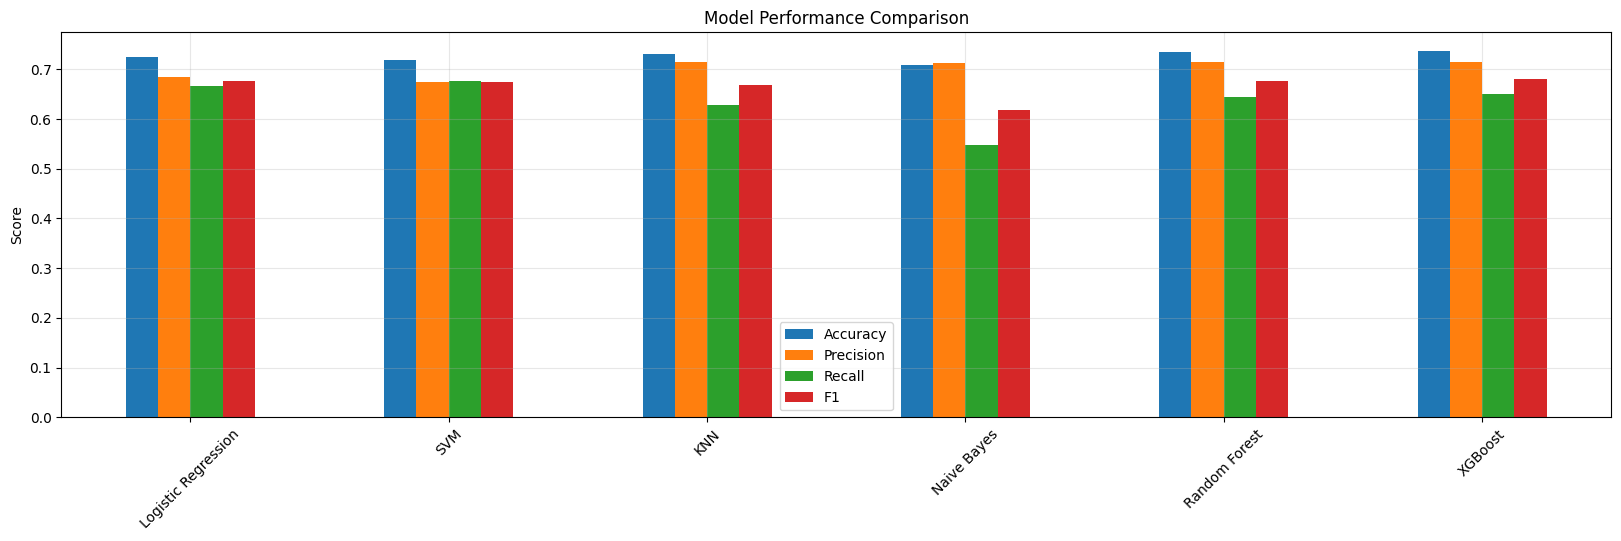

,Accuracy,Precision,Recall,F1,ROC AUC
Logistic Regression,0.724268,0.685393,0.667396,0.676275,0.787939
SVM,0.719547,0.674672,0.676149,0.675410,0.787739
KNN,0.730878,0.713930,0.628009,0.668219,0.793086
Naive Bayes,0.709160,0.712251,0.547046,0.618812,0.766431
Random Forest,0.735600,0.715328,0.643326,0.677419,0.800901
XGBoost,0.737488,0.715663,0.649891,0.681193,0.800817


In [35]:
models = {
    "Logistic Regression": best_logreg,
    "SVM": best_svm,
    "KNN": best_knn,
    "Naive Bayes": best_nb,
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}

results = {}
roc_data = {}

for name, model in models.items():
    
    if name in ["Random Forest", "XGBoost"]:
        X_test_used = X_test
    else:
        X_test_used = X_test_scaled

    y_pred = model.predict(X_test_used)
    y_proba = model.predict_proba(X_test_used)[:,1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    }

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr)

results_df = pd.DataFrame(results).T
results_df[["Accuracy", "Precision", "Recall", "F1"]].plot(kind="bar", figsize=(20,5))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

results_df

### **ROC-AUC**

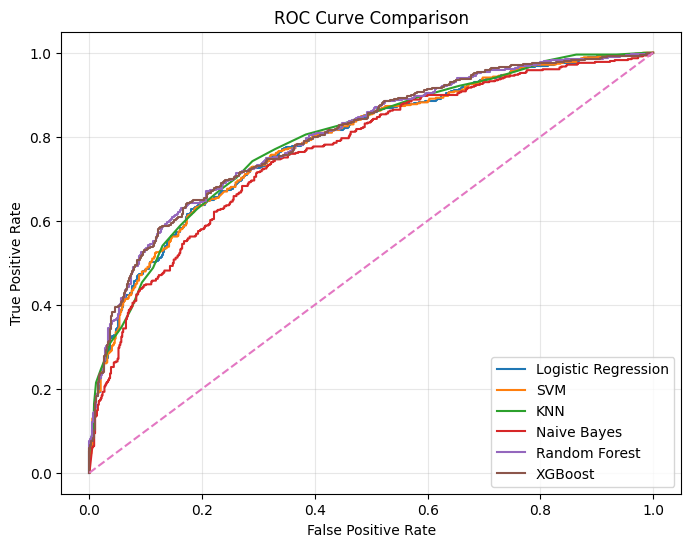

In [36]:
plt.figure(figsize=(8,6))

for name, (fpr, tpr) in roc_data.items():
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

The evaluated models (Logistic Regression, SVM, KNN, Naive Bayes, Random Forest, and XGBoost) show **very similar performance across all metrics**. Accuracy, Precision, Recall, F1-score, and ROC AUC are all within a relatively narrow range, indicating that:

- The problem is **well-defined and stable**
- The engineered features (especially RFM-based) are strong and informative
- More complex models do not drastically outperform simpler ones


Although performance is similar, some models stand out depending on the metric:

- **Random Forest and XGBoost**
  - Best **ROC AUC (~0.80)** → strongest ability to rank customers by likelihood of returning
  - Good balance across all metrics
  - More robust for decision-making

- **KNN**
  - Highest **F1-score (~0.685)** → best balance between Precision and Recall
  - Slightly better at overall classification trade-off

- **Logistic Regression / SVM**
  - Very stable and consistent
  - Slightly lower performance but highly interpretable

- **Naive Bayes**
  - Lower **Recall (~0.55)** → misses many returning customers
  - Less suitable for this use case


**Business-Oriented Interpretation**

The dataset is **moderately imbalanced**:
- Class 0 (non-repeat): 3010  
- Class 1 (repeat): 2284  

The objective is:

- **Loyalty actions** → identify customers likely to return (class 1)
- **Retention actions** → identify customers at risk (class 0)


**Metric Importance**

- **ROC AUC (most important)**  
  - Measures ranking ability → crucial for targeting campaigns  
  - Best models: Random Forest, XGBoost  

- **Recall (important for loyalty actions)**  
  - Higher recall = more returning customers correctly identified  
  - Best: Logistic Regression / SVM / KNN  

- **Precision (important for retention cost efficiency)**  
  - Higher precision = fewer wasted resources  
  - Best: Random Forest  

- **F1-score (balance)**  
  - Best overall: KNN  


- All models perform similarly because the **signal in the data is strong and consistent**
- **Random Forest and XGBoost are slightly better overall**, especially for ranking customers (ROC AUC)
- **KNN offers the best balance**, but may not scale well
- **Naive Bayes underperforms**, especially in identifying returning customers


For this project:

- Use **Random Forest or XGBoost** for production (best overall performance and ranking ability)
- Use **probabilities (not hard predictions)** to:
  - Target high-probability customers → loyalty actions  
  - Target low-probability customers → retention actions  

This approach aligns best with business objectives and maximizes marketing effectiveness.

### **Feature Importance**

**Feature Importance for Non-Tree Models**

Not all models provide native feature importance:

- Tree-based models (Random Forest, XGBoost) compute importance based on splits
- Logistic Regression and linear SVM use coefficients

However:
- KNN is distance-based and does not learn explicit feature weights
- Naive Bayes is probabilistic and assumes feature independence

To address this, we use **permutation importance**, which measures how model performance decreases when a feature is randomly shuffled.

This method:
- Works for any model
- Provides a consistent way to compare importance across models


- SVM importance is only available for linear kernels
- Permutation importance is more computationally expensive
- Results may vary slightly due to randomness


Permutation importance allows us to extend feature importance analysis to all models, enabling a fair comparison across different modeling approaches.

In [39]:
feature_names = X.columns

if best_svm.kernel == "linear":
    svm_importance = pd.Series(
        best_svm.coef_[0],
        index=feature_names
    )
else:
    svm_importance = pd.Series(0, index=X.columns)


knn_perm = permutation_importance(
    best_knn,
    X_test_scaled,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
)
knn_importance = pd.Series(knn_perm.importances_mean, index=X.columns)

nb_perm = permutation_importance(
    best_nb,
    X_test_scaled,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
)
nb_importance = pd.Series(nb_perm.importances_mean, index=X.columns)

logreg_importance = pd.Series(
    best_logreg.coef_[0],
    index=feature_names
).sort_values()

rf_importance = pd.Series(
    best_rf.feature_importances_,
    index=feature_names
).sort_values()

xgb_importance = pd.Series(
    best_xgb.feature_importances_,
    index=feature_names
).sort_values()

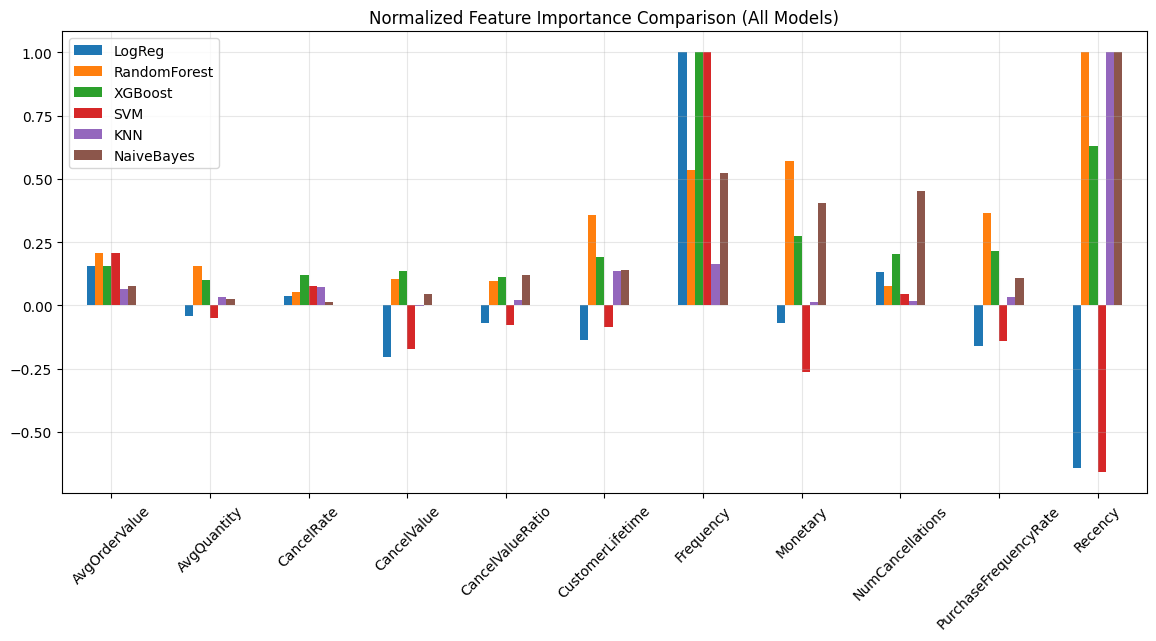

In [40]:
importance_df = pd.DataFrame({
    "LogReg": logreg_importance,
    "RandomForest": rf_importance,
    "XGBoost": xgb_importance,
    "SVM": svm_importance,
    "KNN": knn_importance,
    "NaiveBayes": nb_importance
})

importance_df = importance_df.fillna(0)

# Normalize
importance_df_norm = importance_df / importance_df.max()

importance_df_norm.plot(kind="bar", figsize=(14,6))

plt.title("Normalized Feature Importance Comparison (All Models)")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.show()

The models show a **high level of agreement** on the most important features:

- **Recency, Frequency, and Monetary (RFM)** consistently appear as the most influential variables  
- Secondary features such as **CustomerLifetime and cancellation-related variables** also contribute, but with less importance  

This agreement indicates that:
- The models are capturing the **same underlying customer behavior patterns**
- The feature engineering is robust and meaningful  

This is expected becasue:

When different models: Identify the **same key features** and Extract similar patterns from the data, their performance tends to converge.  

This explains why all models achieved **similar metrics**:  
they are essentially learning the same relationships between customer behavior and repeat purchases.


**Why do Logistic Regression and SVM have negative values?**

- Logistic Regression and linear SVM provide **coefficients**, not importance scores  
- A **positive value** means:
  - The feature increases the probability of being a repeat customer  

- A **negative value** means:
  - The feature decreases that probability  

For example:
- **Recency (negative)** → the longer since last purchase, the lower the chance of returning  
- **Frequency (positive)** → more frequent buyers are more likely to return  

The sign gives **direction**, not just importance  


Why we normalize the variable importance values?

Each model calculates importance differently:
- Tree models → split-based importance  
- Linear models → coefficients  
- Permutation → performance impact  

To compare them, we normalize:

\[
\text{Normalized Importance} = \frac{\text{feature importance}}{\max(\text{importance})}
\]

This means:
- Values are scaled between **-1 and 1 (or 0 and 1 depending on model)**
- The **most important feature = 1**
- Others are expressed **relative to it**

This allows a **fair comparison across models**


These results match the expected results for an RFM problem, since in a RFM-based problem:

- **Recency** is usually the strongest predictor  
- **Frequency** indicates loyalty  
- **Monetary** reflects customer value  

The results confirm:
- Customers who buy **recently and frequently** are more likely to return  
- Cancellation behavior slightly reduces this probability  

---
## **Business Actions Based on Results**

### Loyalty Actions (High Probability Customers)

These customers:
- Purchased recently  
- Buy frequently  
- Have higher monetary value  

Recommended actions:
- Personalized promotions  
- Loyalty programs or rewards  
- Early access to products  
- Upselling and cross-selling  

Goal: **maximize value from already loyal customers**



### Retention Actions (Low Probability Customers)

These customers:
- Have high Recency (inactive for a long time)  
- Lower Frequency  
- Possibly higher cancellation behavior  

Recommended actions:
- Re-engagement campaigns (emails, discounts)  
- Special offers or incentives  
- Reminders or product recommendations  

Goal: **reactivate customers before they churn**


## Final Conclusion

- Models agree on the importance of RFM features  
- Similar feature importance explains similar model performance  
- Results align with expected behavior in customer analytics  

The model provides a strong foundation to:
- Identify valuable customers  
- Optimize marketing strategies  
- Improve customer retention and lifetime value

---
---
---
---

## 7. Modelo: probabilidad de recompra

Modelo supervisado para estimar la probabilidad de que un cliente **vuelva a comprar** después de una fecha de corte.

Estrategia:
- Definimos una **fecha de corte** (`cutoff_date`).
- Con los datos **antes** de esa fecha construimos variables por cliente (RFM simplificado: recencia, frecuencia, gasto total, ticket medio, país, etc.).
- Con los datos **después** de la fecha etiquetamos si el cliente **recompró (1)** o **no recompró (0)**.
- Entrenamos una **regresión logística** para predecir esa probabilidad de recompra.

## 8. Modelo: explicabilidad
indicar las variables más relevantes del modelo. Con Dalex o más sencillo, los propios  tiene manera de obtener las variables:   
Ej. 

from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model)
plt.show()

